<a href="https://colab.research.google.com/github/sharmalalbabu266-ctrl/BSC_research_proposal/blob/main/Statsical%20analysis%20of%20share%20market%20volatility%20using%20brownian%20motion0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots in notebook
%matplotlib inline

plt.rcParams["figure.figsize"] = (12,6)

In [5]:
filename = "/nepsealpha_export_price_NEPSE_2021-07-29_2026-07-18_unadjusted.csv"

df = pd.read_csv(filename)

print(df.head())
print(df.columns.tolist())

  Symbol        Date     Open     High      Low    Close Percent Change  \
0  NEPSE  2026-07-17  2599.43  2677.64  2598.24  2677.54         3.06 %   
1  NEPSE  2026-07-16  2605.26  2606.89  2581.09  2597.80         0.28 %   
2  NEPSE  2026-07-15  2577.24  2601.99  2576.61  2590.29         0.54 %   
3  NEPSE  2026-07-14  2569.20  2584.30  2546.69  2576.29         0.23 %   
4  NEPSE  2026-07-13  2599.66  2607.04  2566.27  2570.18        -1.17 %   

             Volume Turn Over  
0  4,575,094,723.51         -  
1  4,562,950,700.46         -  
2  4,170,398,049.64         -  
3  8,417,570,425.82         -  
4  7,468,416,116.81         -  
['Symbol', 'Date', 'Open', 'High', 'Low', 'Close', 'Percent Change', 'Volume', 'Turn Over']


In [7]:
print(df.columns)

Index(['Symbol', 'Date', 'Open', 'High', 'Low', 'Close', 'Percent Change',
       'Volume', 'Turn Over'],
      dtype='object')


In [9]:
price = df["Close"]

In [11]:
# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Sort by date
df = df.sort_values("Date")

# Reset index
df = df.reset_index(drop=True)

# Select closing price
price = pd.to_numeric(df["Close"], errors="coerce")

# Remove missing values
price = price.dropna()

print(price.head())

0    3079.82
1    3081.07
2    3085.07
3    3111.09
4    3123.15
Name: Close, dtype: float64


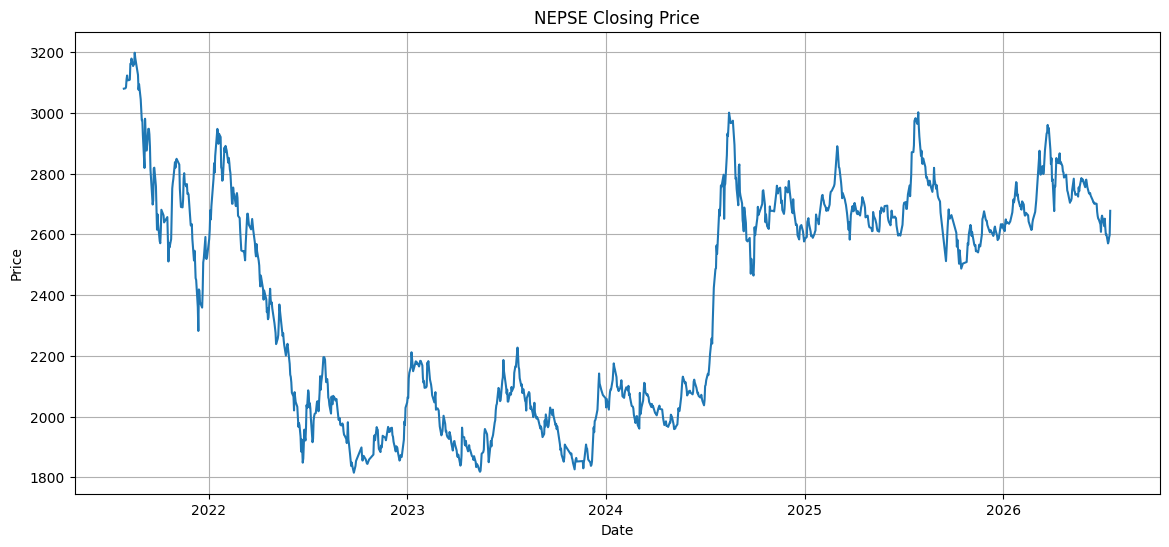

In [13]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"][:len(price)], price)

plt.title("NEPSE Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.grid(True)

plt.show()

In [15]:
log_returns = np.log(price / price.shift(1))

log_returns = log_returns.dropna()

print(log_returns.head())

1    0.000406
2    0.001297
3    0.008399
4    0.003869
5   -0.005040
Name: Close, dtype: float64


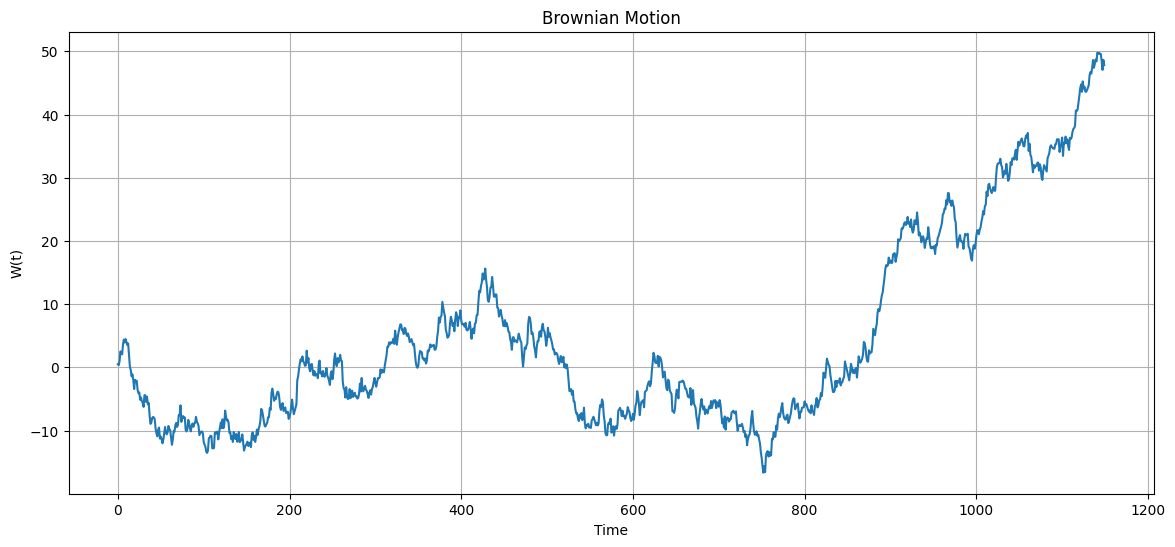

In [17]:
np.random.seed(42)

N = len(log_returns)

dt = 1

dW = np.random.normal(0, np.sqrt(dt), N)

W = np.cumsum(dW)

plt.figure(figsize=(14,6))

plt.plot(W)

plt.title("Brownian Motion")

plt.xlabel("Time")

plt.ylabel("W(t)")

plt.grid(True)

plt.show()

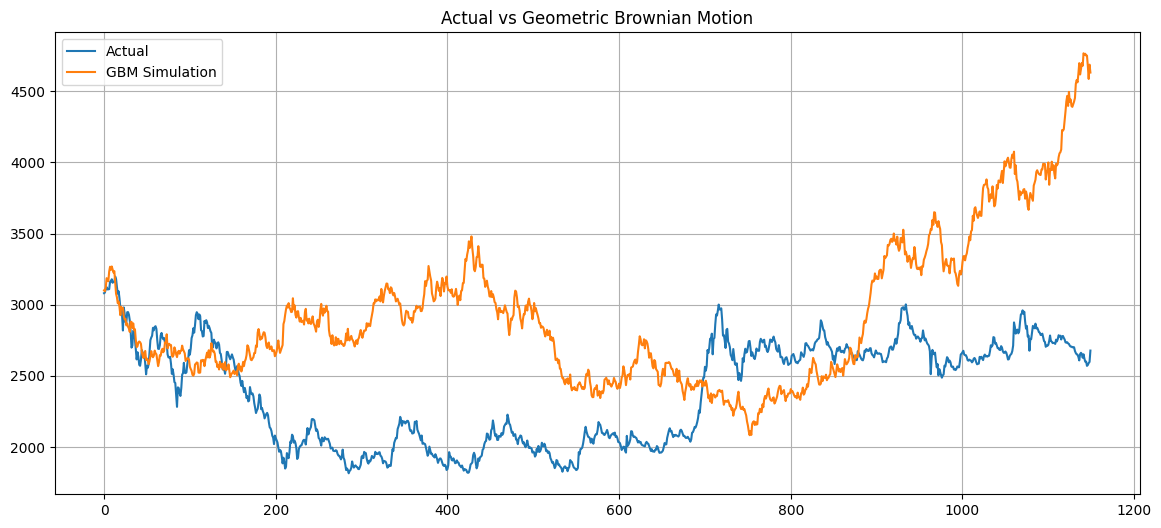

In [20]:
S0 = price.iloc[0]

time = np.arange(N)

# Define mu (drift) and sigma (volatility) from log_returns
mu = log_returns.mean()
sigma = log_returns.std()

GBM = S0 * np.exp((mu - 0.5*sigma**2)*time + sigma*W)

plt.figure(figsize=(14,6))

plt.plot(price.values[1:], label="Actual")

plt.plot(GBM, label="GBM Simulation")

plt.legend()

plt.grid(True)

plt.title("Actual vs Geometric Brownian Motion")

plt.show()

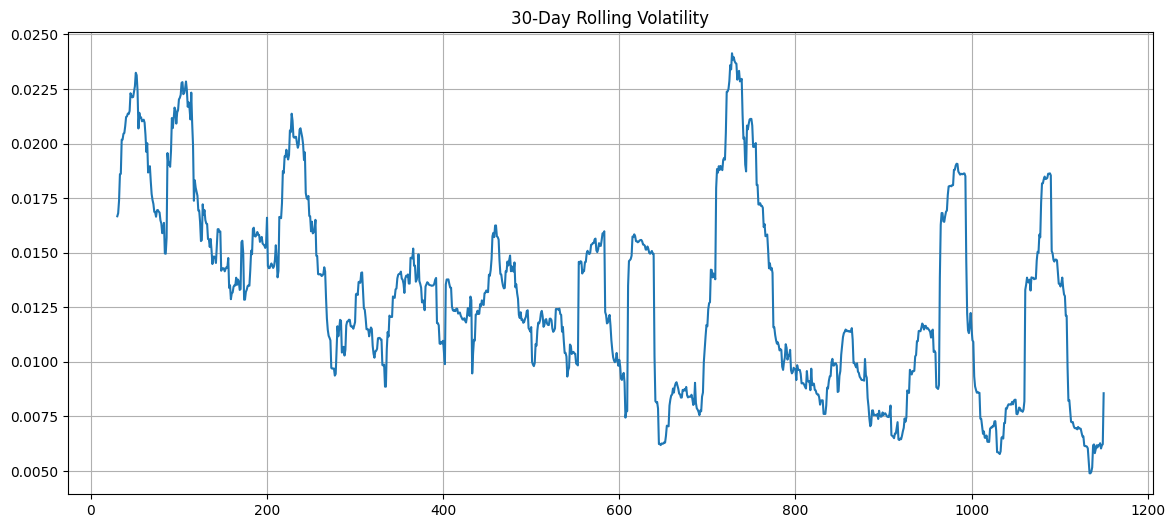

In [22]:
rolling_vol = log_returns.rolling(30).std()

plt.figure(figsize=(14,6))

plt.plot(rolling_vol)

plt.title("30-Day Rolling Volatility")

plt.grid(True)

plt.show()

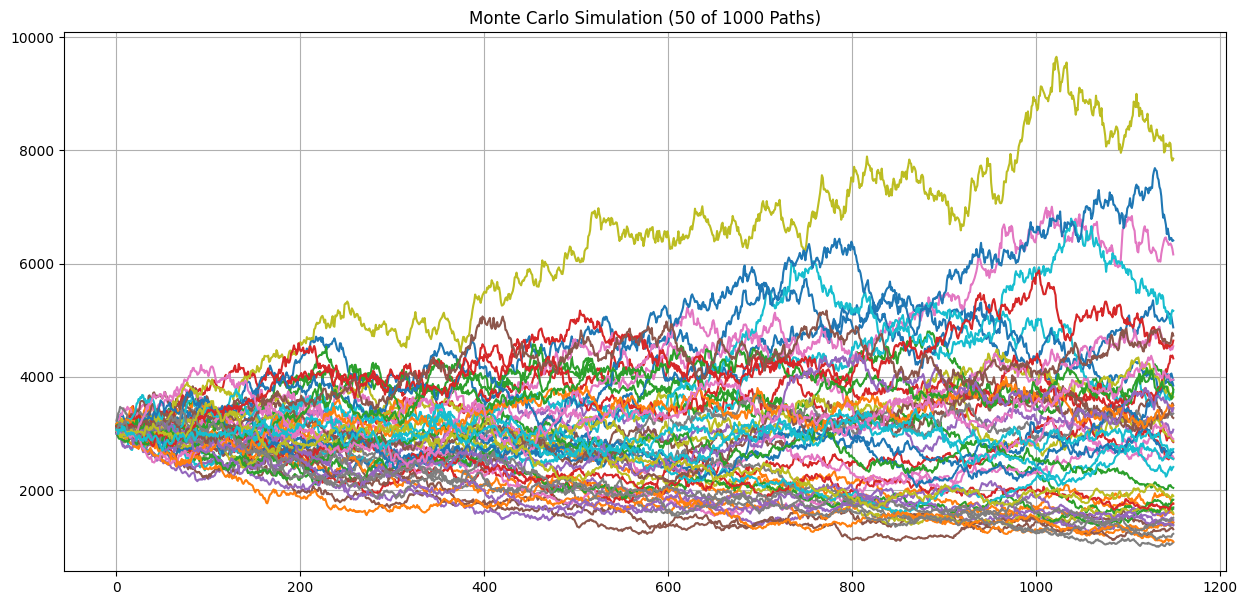

In [24]:
simulations = 1000

results = np.zeros((N, simulations))

for i in range(simulations):

    W = np.cumsum(np.random.normal(0,1,N))

    results[:,i] = S0*np.exp(
        (mu-0.5*sigma**2)*np.arange(N)+sigma*W
    )

plt.figure(figsize=(15,7))

plt.plot(results[:,:50])

plt.title("Monte Carlo Simulation (50 of 1000 Paths)")

plt.grid(True)

plt.show()

In [26]:
annual_volatility = sigma*np.sqrt(252)

print("Daily Volatility :", sigma)

print("Annualized Volatility :", annual_volatility)

Daily Volatility : 0.01372532515863823
Annualized Volatility : 0.21788278219952945


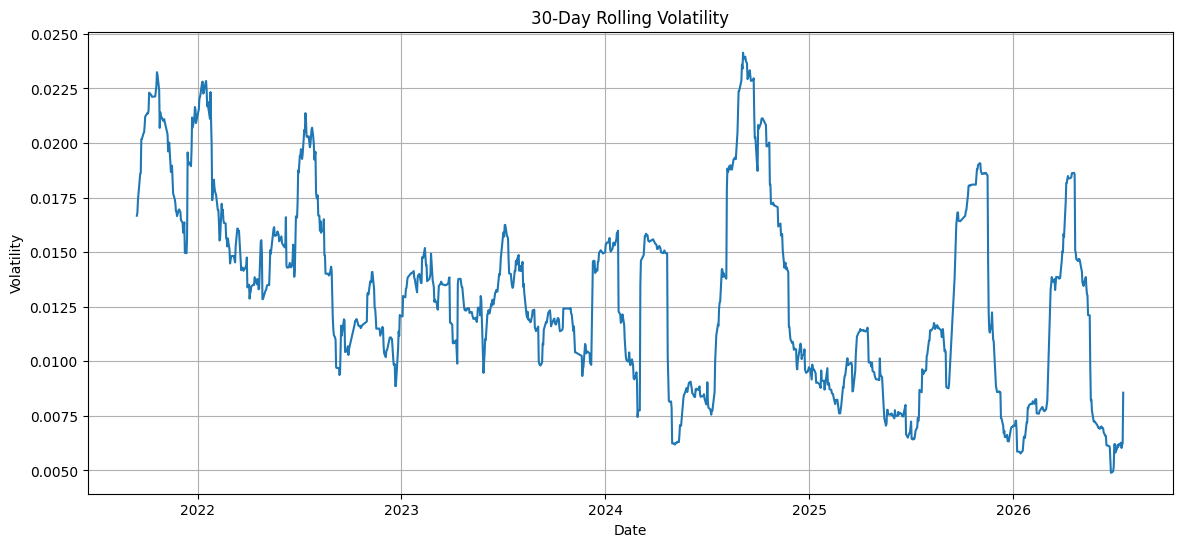

In [28]:
rolling_vol = log_returns.rolling(30).std()

plt.figure(figsize=(14,6))

plt.plot(df["Date"].iloc[1:], rolling_vol)

plt.title("30-Day Rolling Volatility")

plt.xlabel("Date")

plt.ylabel("Volatility")

plt.grid(True)

plt.show()

In [30]:
from scipy.stats import skew, kurtosis

print("Mean       :", log_returns.mean())

print("Variance   :", log_returns.var())

print("Std Dev    :", log_returns.std())

print("Skewness   :", skew(log_returns))

print("Kurtosis   :", kurtosis(log_returns))

print("Minimum    :", log_returns.min())

print("Maximum    :", log_returns.max())

Mean       : -0.00012171538363655394
Variance   : 0.00018838455071034751
Std Dev    : 0.01372532515863823
Skewness   : 0.5173136735888046
Kurtosis   : 2.238550509163213
Minimum    : -0.06187739423328267
Maximum    : 0.05833519605910542


In [32]:
!pip install arch

In [34]:
from arch import arch_model

returns = log_returns * 100

model = arch_model(
    returns,
    vol="GARCH",
    p=1,
    q=1
)

result = model.fit()

print(result.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 4637.45360280435
Iteration:      2,   Func. Count:     14,   Neg. LLF: 382190.5902604222
Iteration:      3,   Func. Count:     21,   Neg. LLF: 2015.8347928797787
Iteration:      4,   Func. Count:     29,   Neg. LLF: 1957.138838208201
Iteration:      5,   Func. Count:     35,   Neg. LLF: 1943.5599534717273
Iteration:      6,   Func. Count:     41,   Neg. LLF: 1943.4273435444093
Iteration:      7,   Func. Count:     47,   Neg. LLF: 1939.9307397751184
Iteration:      8,   Func. Count:     52,   Neg. LLF: 1939.928735925302
Iteration:      9,   Func. Count:     57,   Neg. LLF: 1939.9287183944468
Iteration:     10,   Func. Count:     62,   Neg. LLF: 1939.9287179477033
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1939.9287179477033
            Iterations: 10
            Function evaluations: 62
            Gradient evaluations: 10
                     Constant Mean - GARCH Model Results         

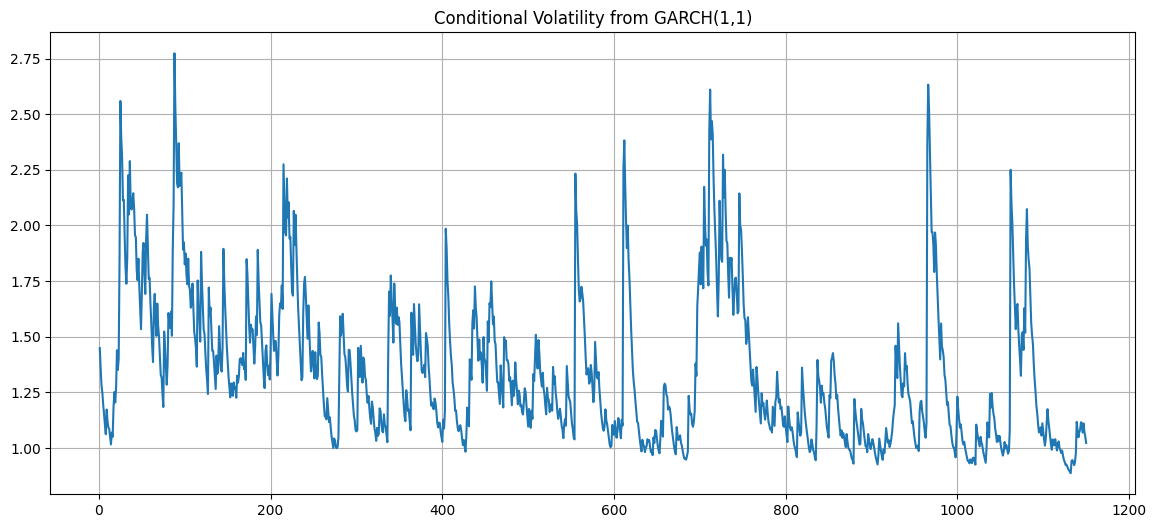

In [36]:
plt.figure(figsize=(14,6))

plt.plot(result.conditional_volatility)

plt.title("Conditional Volatility from GARCH(1,1)")

plt.grid(True)

plt.show()

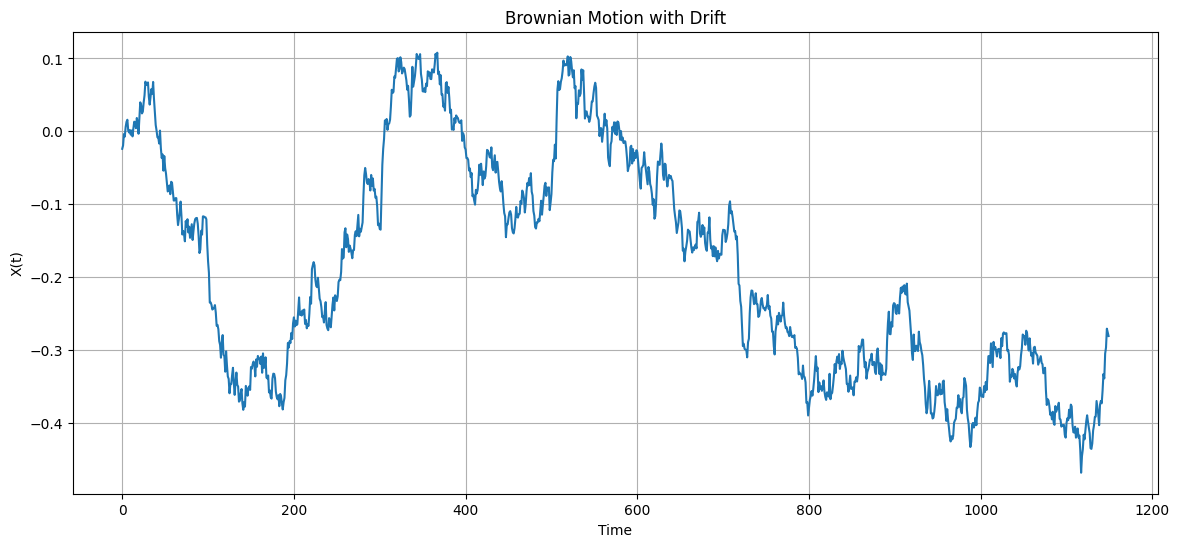

In [38]:
np.random.seed(100)

N = len(log_returns)

dt = 1

drift = mu

sigma = log_returns.std()

W = np.random.normal(0, np.sqrt(dt), N)

W = np.cumsum(W)

X = drift*np.arange(N) + sigma*W

plt.figure(figsize=(14,6))

plt.plot(X)

plt.title("Brownian Motion with Drift")

plt.xlabel("Time")

plt.ylabel("X(t)")

plt.grid(True)

plt.show()

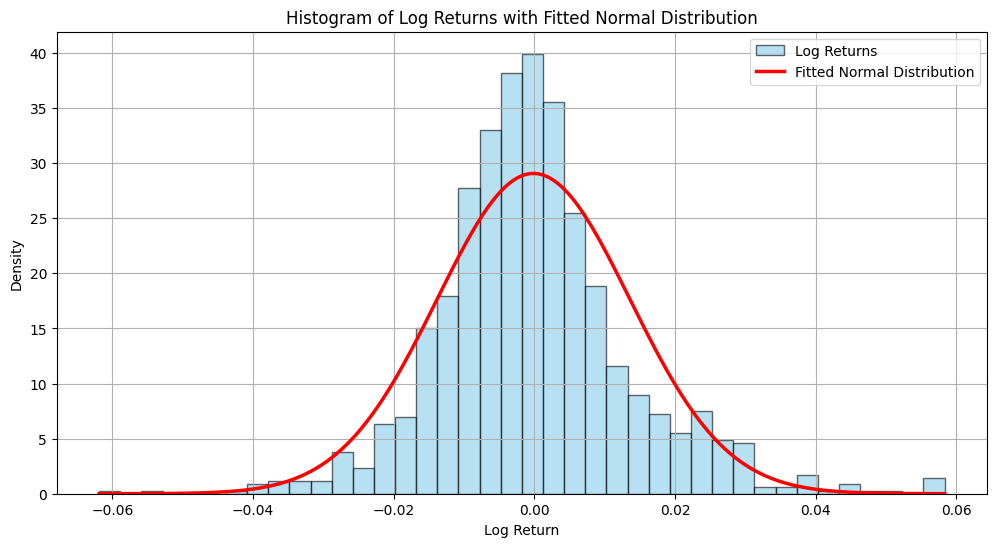

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Mean and standard deviation
mu = log_returns.mean()
sigma = log_returns.std()

plt.figure(figsize=(12,6))

# Histogram (density=True scales histogram to a probability density)
plt.hist(
    log_returns,
    bins=40,
    density=True,
    alpha=0.6,
    color='skyblue',
    edgecolor='black',
    label='Log Returns'
)

# Normal distribution curve
x = np.linspace(log_returns.min(), log_returns.max(), 500)
y = norm.pdf(x, mu, sigma)

plt.plot(
    x,
    y,
    'r',
    linewidth=2.5,
    label='Fitted Normal Distribution'
)

plt.title("Histogram of Log Returns with Fitted Normal Distribution")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

In [44]:
!pip install arch -q

from arch import arch_model

returns = log_returns * 100

model = arch_model(
    returns,
    vol='GARCH',
    p=1,
    q=1,
    mean='Constant'
)

garch_result = model.fit(disp="off")

print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1939.93
Distribution:                  Normal   AIC:                           3887.86
Method:            Maximum Likelihood   BIC:                           3908.05
                                        No. Observations:                 1150
Date:                Tue, Jul 21 2026   Df Residuals:                     1149
Time:                        15:05:40   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         1.6925e-03  3.801e-02  4.453e-02      0.964 

In [46]:
forecast = garch_result.forecast(horizon=30)

future_variance = forecast.variance.iloc[-1]
future_volatility = np.sqrt(future_variance)

print("Forecasted Volatility (%)")
print(future_volatility)

Forecasted Volatility (%)
h.01    1.434144
h.02    1.432730
h.03    1.431412
h.04    1.430183
h.05    1.429037
h.06    1.427969
h.07    1.426972
h.08    1.426043
h.09    1.425177
h.10    1.424369
h.11    1.423616
h.12    1.422914
h.13    1.422260
h.14    1.421650
h.15    1.421081
h.16    1.420551
h.17    1.420058
h.18    1.419597
h.19    1.419168
h.20    1.418768
h.21    1.418395
h.22    1.418048
h.23    1.417724
h.24    1.417423
h.25    1.417141
h.26    1.416879
h.27    1.416635
h.28    1.416408
h.29    1.416195
h.30    1.415998
Name: 1150, dtype: float64


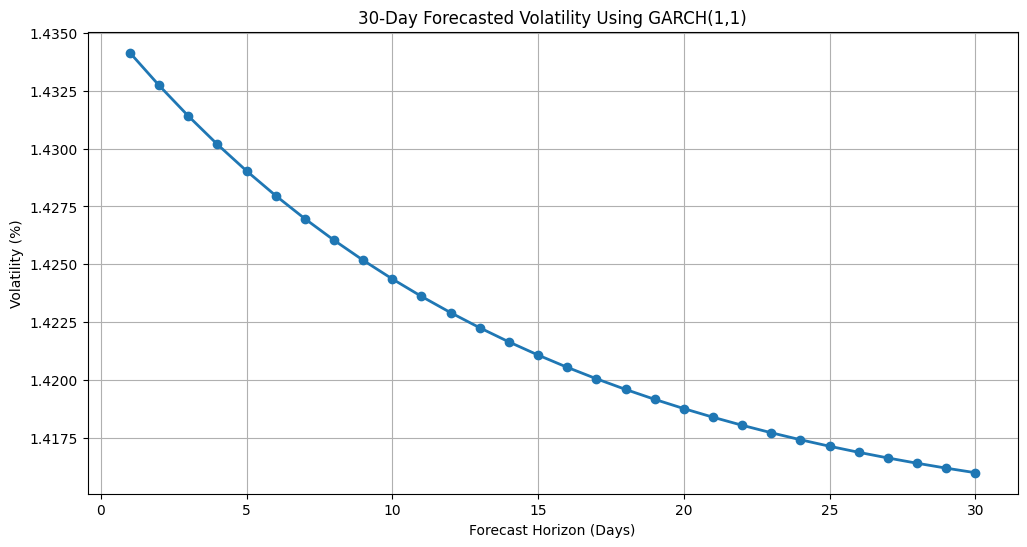

In [48]:
plt.figure(figsize=(12,6))

plt.plot(
    range(1,31),
    future_volatility.values,
    marker='o',
    linewidth=2
)

plt.title("30-Day Forecasted Volatility Using GARCH(1,1)")
plt.xlabel("Forecast Horizon (Days)")
plt.ylabel("Volatility (%)")
plt.grid(True)

plt.show()

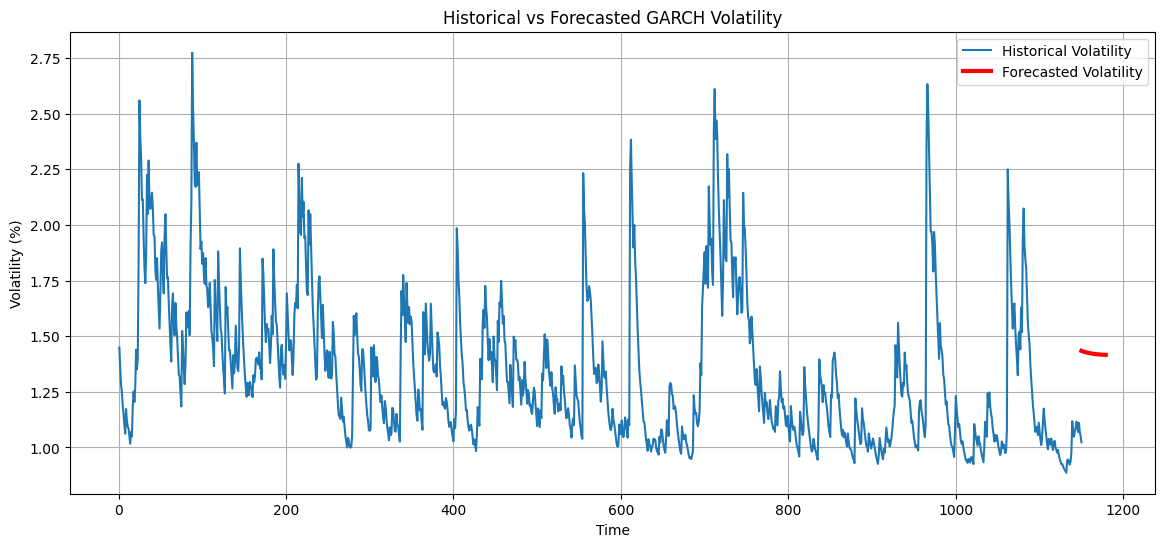

In [50]:
historical_vol = garch_result.conditional_volatility

plt.figure(figsize=(14,6))

plt.plot(
    historical_vol.index,
    historical_vol,
    label="Historical Volatility"
)

plt.plot(
    range(len(historical_vol), len(historical_vol)+30),
    future_volatility.values,
    color='red',
    linewidth=3,
    label="Forecasted Volatility"
)

plt.title("Historical vs Forecasted GARCH Volatility")
plt.xlabel("Time")
plt.ylabel("Volatility (%)")
plt.legend()
plt.grid(True)

plt.show()

In [52]:
import numpy as np

confidence_levels = [0.95, 0.99]

for c in confidence_levels:
    var = np.percentile(log_returns, (1-c)*100)
    print(f"Historical VaR ({int(c*100)}%): {var:.6f}")

Historical VaR (95%): -0.020728
Historical VaR (99%): -0.034285


In [54]:
from scipy.stats import norm

mu = log_returns.mean()
sigma = log_returns.std()

VaR95 = norm.ppf(0.05, mu, sigma)
VaR99 = norm.ppf(0.01, mu, sigma)

print("Parametric VaR (95%) =", VaR95)
print("Parametric VaR (99%) =", VaR99)

Parametric VaR (95%) = -0.022697866251910944
Parametric VaR (99%) = -0.032051596386953866


In [56]:
VaR95 = np.percentile(log_returns,5)
VaR99 = np.percentile(log_returns,1)

ES95 = log_returns[log_returns <= VaR95].mean()
ES99 = log_returns[log_returns <= VaR99].mean()

print("Expected Shortfall (95%) =", ES95)
print("Expected Shortfall (99%) =", ES99)

Expected Shortfall (95%) = -0.028161080756264893
Expected Shortfall (99%) = -0.04093083661769104


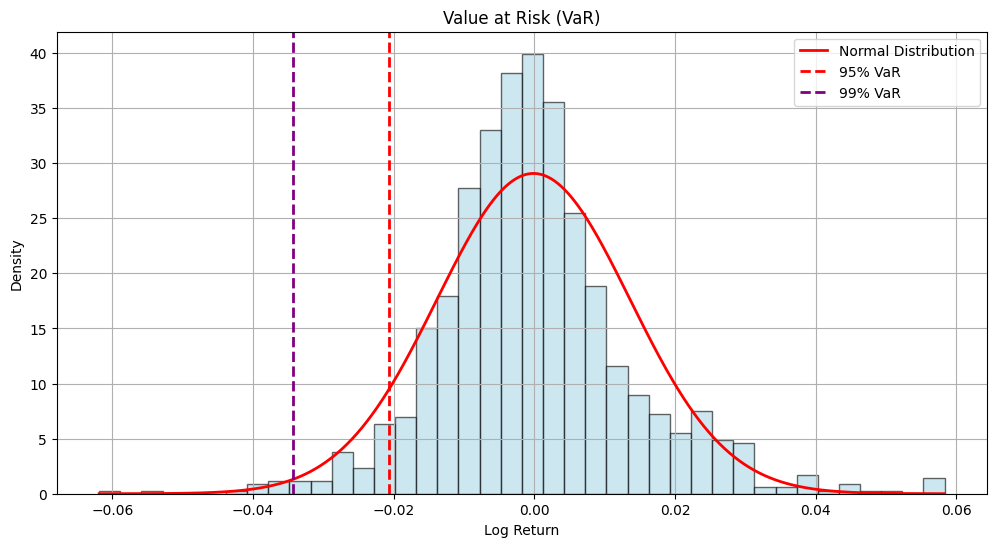

In [58]:
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.figure(figsize=(12,6))

# Histogram
plt.hist(log_returns,
         bins=40,
         density=True,
         alpha=0.6,
         color='lightblue',
         edgecolor='black')

# Normal curve
x = np.linspace(log_returns.min(),
                log_returns.max(),
                500)

plt.plot(x,
         norm.pdf(x,mu,sigma),
         'r',
         linewidth=2,
         label='Normal Distribution')

# VaR lines
plt.axvline(VaR95,
            color='red',
            linestyle='--',
            linewidth=2,
            label='95% VaR')

plt.axvline(VaR99,
            color='purple',
            linestyle='--',
            linewidth=2,
            label='99% VaR')

plt.title("Value at Risk (VaR)")

plt.xlabel("Log Return")

plt.ylabel("Density")

plt.legend()

plt.grid(True)

plt.show()

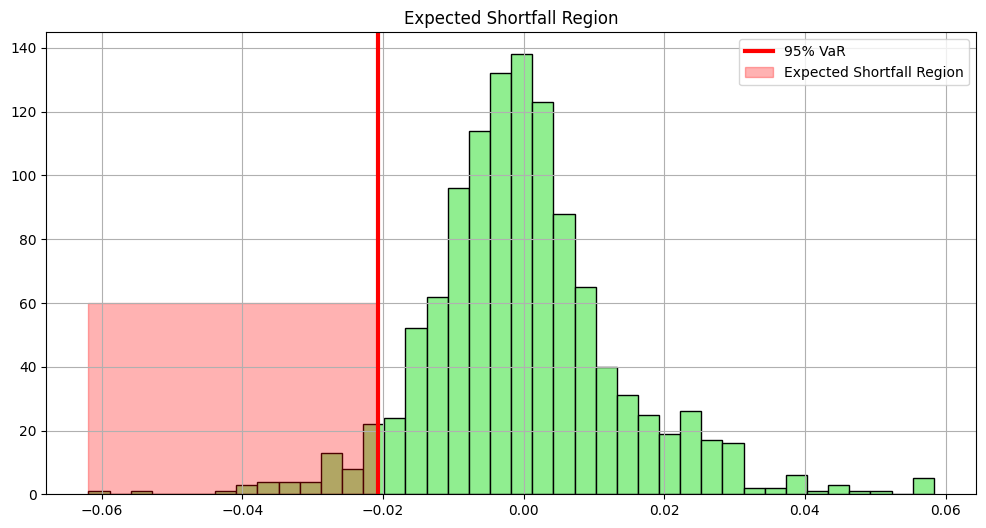

In [59]:
plt.figure(figsize=(12,6))

plt.hist(log_returns,
         bins=40,
         color='lightgreen',
         edgecolor='black')

plt.axvline(VaR95,
            color='red',
            linewidth=3,
            label='95% VaR')

plt.fill_betweenx([0,60],
                  log_returns.min(),
                  VaR95,
                  color='red',
                  alpha=0.3,
                  label='Expected Shortfall Region')

plt.legend()

plt.title("Expected Shortfall Region")

plt.grid(True)

plt.show()